# HCC Study

This notebook walks through the HCC analysis in a structured way.

The main stages are:

1. load MS1, MS2, and sample metadata,
2. clean and align the samples,
3. prepare the abundance matrix for MetVAE,
4. load the trained model checkpoint and inspect training loss,
5. estimate a sparse MetVAE correlation network,
6. export a correlation-only graph layered onto the cosine graph, and
7. repeat the same graph construction for a conventional correlation baseline.

Timing is recorded for the key computational steps and summarized at the end.

In [1]:
import os
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.patches import Patch

from metvae.model import MetVAE

%matplotlib inline

sns.set_theme(style="whitegrid")

step_times = {}

def print_step_time(step_name, start_time):
    elapsed = time.perf_counter() - start_time
    step_times[step_name] = elapsed
    print(f"{step_name} finished in {elapsed:.2f} seconds")

def build_upper_triangle_edge_table(corr_matrix_df):
    """Convert a symmetric correlation matrix into a long edge table."""
    corr_matrix_df = corr_matrix_df.copy()
    corr_matrix_df.index.name = None
    corr_matrix_df.columns.name = None

    mask = np.triu(np.ones(corr_matrix_df.shape, dtype=bool), k=1)
    corr_upper = corr_matrix_df.where(mask)
    edge_table = corr_upper.stack().reset_index()
    edge_table.columns = ["source", "target", "correlation"]
    edge_table = edge_table.sort_values("correlation", key=np.abs, ascending=False)
    edge_table["source"] = edge_table["source"].astype(str)
    edge_table["target"] = edge_table["target"].astype(str)
    return edge_table

def build_correlation_graph(edge_table, cutoff, template_graph=None):
    """Create a GraphML-ready NetworkX graph from a long correlation edge table."""
    selected = edge_table.loc[edge_table["correlation"].abs() >= cutoff, ["source", "target", "correlation"]].copy()
    graph = nx.Graph()
    edge_type = f"Correlation_cutoff{cutoff:g}"

    for row in selected.itertuples(index=False):
        graph.add_edge(
            row.source,
            row.target,
            EdgeScore=float(row.correlation),
            EdgeType=edge_type,
            id=edge_type,
        )

    if template_graph is not None:
        for node in graph.nodes():
            if node in template_graph.nodes():
                graph.nodes[node].update(template_graph.nodes[node])

    return graph, selected

def plot_training_loss(train_loss, output_path, window_size=25):
    """Plot a readable training-loss diagnostic and save it as a PDF."""
    df_loss = pd.DataFrame(
        {
            "Epoch": np.arange(1, len(train_loss) + 1),
            "Training Loss": pd.Series(train_loss, dtype=float),
        }
    )
    df_loss.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_loss.dropna(subset=["Training Loss"], inplace=True)
    df_loss["Smoothed Loss"] = df_loss["Training Loss"].rolling(window=window_size, min_periods=1).mean()

    zoom_start = max(2, int(np.ceil(len(df_loss) * 0.1)))
    df_zoom = df_loss[df_loss["Epoch"] >= zoom_start].copy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    axes[0].plot(df_loss["Epoch"], df_loss["Training Loss"], color="#4C72B0", alpha=0.35, linewidth=1.5, label="Raw loss")
    axes[0].plot(df_loss["Epoch"], df_loss["Smoothed Loss"], color="#C44E52", linewidth=2.0, label=f"{window_size}-epoch moving average")
    axes[0].set_yscale("log")
    axes[0].set_title("Full training trajectory")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Training loss")
    axes[0].legend(frameon=False)

    axes[1].plot(df_zoom["Epoch"], df_zoom["Training Loss"], color="#4C72B0", alpha=0.35, linewidth=1.5)
    axes[1].plot(df_zoom["Epoch"], df_zoom["Smoothed Loss"], color="#C44E52", linewidth=2.0)
    axes[1].set_title("Later-epoch zoom")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Training loss")

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    plt.show()

    return df_loss

## 1. Load the input data

We start by loading the MS1 feature matrix, the MS2 annotation table, and the sample metadata. The quick previews below are only meant to confirm that the files loaded correctly before we begin filtering and alignment.

In [2]:
step_start = time.perf_counter()

# MS1 data
df_ms1 = pd.read_csv('../data/hcc_ms1.csv', index_col=0)
df_ms1.index = df_ms1.index.astype(str)

# MS2 data
df_ms2 = pd.read_table('../data/hcc_ms2.tsv')
df_ms2 = df_ms2.set_index('#Scan#')
df_ms2.index = df_ms2.index.astype(str)
df_ms2.sort_values(by='Compound_Name', inplace=True)

# Sample metadata
smd = pd.read_table('../data/hcc_sample_metadata.txt')
smd.set_index('host_subject_id', inplace=True)

print_step_time('Load input tables', step_start)

print('MS1 shape:', df_ms1.shape)
print('MS2 shape:', df_ms2.shape)
print('Metadata shape:', smd.shape)

display(df_ms1.head())
display(df_ms2.head())
display(smd.head())

Load input tables finished in 0.32 seconds
MS1 shape: (7713, 449)
MS2 shape: (2139, 45)
Metadata shape: (452, 53)


,row m/z,row retention time,correlation group ID,annotation network number,best ion,auto MS2 verify,identified by n=,partners,neutral M mass,SS143_RE2_01_7471.mzXML Peak area,...,SS91_RH7_01_7408.mzXML Peak area,SS65_RF5_01_7378.mzXML Peak area,SS4_RA4_01_7308.mzXML Peak area,SS39_RD3_01_7349.mzXML Peak area,SS85_RH1_01_7401.mzXML Peak area,SS78_RG6_01_7393.mzXML Peak area,SS8_RA8_01_7314.mzXML Peak area,SS53_RE5_01_7365.mzXML Peak area,SS93_RH9_01_7410.mzXML Peak area,Unnamed: 449
row ID,,,,,,,,,,,,,,,,,,,,,
1,90.507336,14.711031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.729032e+04,...,3.984643e+04,6.207472e+04,4.711460e+04,3.124769e+04,3.695430e+04,4.775607e+04,5.016101e+04,4.273617e+04,4.289156e+04,NaN
2,97.009823,14.711820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.621003e+04,...,5.497772e+04,5.006906e+04,2.637787e+04,5.162720e+04,4.703117e+04,4.765542e+04,5.089295e+04,3.949850e+04,4.294513e+04,NaN
3,98.512122,14.871233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.706221e+06,...,3.979941e+06,3.273772e+06,3.317892e+06,3.790327e+06,3.190978e+06,4.089099e+06,3.674933e+06,2.902031e+06,3.421487e+06,NaN
4,99.512410,11.727107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.912212e+05,...,5.256321e+04,3.109291e+04,1.983272e+04,6.152516e+04,1.135546e+05,6.762894e+04,3.816150e+04,1.274469e+04,5.170462e+04,NaN
5,99.512521,14.708522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.073736e+05,...,5.746619e+05,5.285471e+05,4.880767e+05,5.344626e+05,5.678752e+05,5.615138e+05,7.487015e+05,4.981058e+05,5.575404e+05,NaN


,SpectrumID,Compound_Name,Ion_Source,Instrument,Compound_Source,PI,Data_Collector,Adduct,Precursor_MZ,ExactMass,...,MoleculeExplorerDatasets,MoleculeExplorerFiles,InChIKey,InChIKey-Planar,superclass,class,subclass,npclassifier_superclass,npclassifier_class,npclassifier_pathway
#Scan#,,,,,,,,,,,,,,,,,,,,,
2956,CCMSLIB00005465060,"""(4R)-4-((3R,5R,6R,7S,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-NQTCFNIESA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids
6504,CCMSLIB00005465106,"""(4R)-4-((3R,5R,6S,7R,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-KREOYVNCSA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids
4718,CCMSLIB00005465106,"""(4R)-4-((3R,5R,6S,7R,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-KREOYVNCSA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids
4378,CCMSLIB00005465007,"""(4R)-4-((3R,5R,6S,7R,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-KREOYVNCSA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids
4796,CCMSLIB00005465007,"""(4R)-4-((3R,5R,6S,7R,9S,10R,12S,13R,14S,17R)-...",ESI,qTof,crude,Dorrestein,Emily Gentry,2M+H,849.572,424.283,...,0,0,COCMFMBNEAMQMA-KREOYVNCSA-N,COCMFMBNEAMQMA,NaN,NaN,NaN,Steroids,Cholane steroids,Terpenoids


,age,age_units,antibiotics,body_habitat,body_product,body_site,cage,collection_timestamp,description,diet,...,FVB,IgA,IgM,CD8KO,HCC,SI,T1d,TGFbRflox/flox,TGFbrko,NASH
host_subject_id,,,,,,,,,,,,,,,,,,,,,
SS1,27,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 1,2016-05-05,MupHe-HFD (6M),HFD,...,False,True,True,False,False,False,False,False,False,True
SS10,27,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 4,2016-06-20,MupHe-HFD (6M),HFD,...,False,True,True,False,False,False,False,False,False,True
SS100,28,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 49,2016-06-30,IgAkMup-HFD (6M),HFD,...,False,False,True,False,False,False,False,False,False,True
SS101,27,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 50,2016-06-30,IgAkMup-HFD (6M),HFD,...,False,False,True,False,False,False,False,False,False,True
SS102,27,weeks,No,UBERON:gastro-intestinal system,UBERON:feces,UBERON:colon,Cage 50,2016-06-30,IgAkMup-HFD (6M),HFD,...,False,False,True,False,False,False,False,False,False,True


## 2. Standardize metadata labels and inspect key covariates

Before aligning samples, we clean the metadata fields used later in the analysis. These summaries help confirm that the HCC, diet, and antibiotic variables look as expected.

In [3]:
smd['HCC'] = smd['HCC'].map({True: 'Yes', False: 'No'})
smd['antibiotics'] = smd['antibiotics'].str.strip().replace(
    {'Yes (Ampicillin, Vancomycin, Neomycin sulfate and Metronidazole )': 'Yes'}
)

print('HCC counts:')
display(smd['HCC'].value_counts())

print('Diet counts:')
display(smd['diet'].value_counts())

print('Antibiotics counts:')
display(smd['antibiotics'].value_counts())

print('Age summary:')
display(smd[['age']].describe())

print('HCC by diet:')
display(pd.crosstab(smd['HCC'], smd['diet'], margins=True))

HCC counts:


HCC
No     244
Yes    208
Name: count, dtype: int64

Diet counts:


diet
HFD    338
NC     114
Name: count, dtype: int64

Antibiotics counts:


antibiotics
No     425
Yes     27
Name: count, dtype: int64

Age summary:


,age
count,452.000000
mean,35.402655
std,13.641166
min,5.000000
25%,25.000000
50%,39.500000
75%,48.000000
max,56.000000


HCC by diet:


diet,HFD,NC,All
HCC,,,
No,139,105,244
Yes,199,9,208
All,338,114,452


## 3. Remove duplicate MS1 columns, exclude antibiotic-treated samples, and align IDs

This is the main sample-preparation step. We deduplicate the MS1 sample columns, restrict the metadata to samples without antibiotics, and then keep only the sample IDs shared by MS1 and the filtered metadata.

In [4]:
step_start = time.perf_counter()

df_ms1 = df_ms1.iloc[:, 9:]
df_ms1.columns = list(map(lambda x: x.split('_')[0], df_ms1.columns))
ms1_cols_before = df_ms1.columns
n_ms1_before = len(ms1_cols_before)
n_meta_before = smd.shape[0]

print(f'Start - MS1 sample columns: {n_ms1_before}, metadata rows: {n_meta_before}')

# Remove duplicate MS1 sample columns.
mask_unique = ~df_ms1.columns.duplicated()
n_dups = n_ms1_before - mask_unique.sum()
df_ms1 = df_ms1.loc[:, mask_unique]
n_ms1_after_dedup = df_ms1.shape[1]
print(f'Step 1 - Removed duplicate MS1 columns: {n_dups} (kept {n_ms1_after_dedup})')

# Restrict to samples without antibiotic treatment.
smd = smd[smd['antibiotics'].eq('No')].copy()
n_filtered_antibiotics = n_meta_before - smd.shape[0]
print(f"Step 2 - Excluded by antibiotics != 'No': {n_filtered_antibiotics} (kept {smd.shape[0]})")

# Align sample IDs and preserve metadata row order.
samp_ids = smd.index.intersection(df_ms1.columns)
dropped_meta_only = smd.shape[0] - len(samp_ids)
dropped_ms1_only = len(df_ms1.columns) - len(samp_ids)
print(
    f'Step 3 - Alignment drops: {dropped_meta_only} metadata-only, '
    f'{dropped_ms1_only} MS1-only (aligned kept: {len(samp_ids)})'
)

df_ms1 = df_ms1.loc[:, samp_ids]
smd = smd.loc[samp_ids].copy()

print_step_time('Preprocess and align samples', step_start)

print('Final MS1 shape:', df_ms1.shape)
print('MS2 shape:', df_ms2.shape)
print('Final metadata shape:', smd.shape)

display(smd['HCC'].value_counts())
display(smd['diet'].value_counts())

Start - MS1 sample columns: 440, metadata rows: 452
Step 1 - Removed duplicate MS1 columns: 1 (kept 439)
Step 2 - Excluded by antibiotics != 'No': 27 (kept 425)
Step 3 - Alignment drops: 14 metadata-only, 28 MS1-only (aligned kept: 411)
Preprocess and align samples finished in 0.01 seconds
Final MS1 shape: (7713, 411)
MS2 shape: (2139, 45)
Final metadata shape: (411, 53)


HCC
No     230
Yes    181
Name: count, dtype: int64

diet
HFD    302
NC     109
Name: count, dtype: int64

## 4. Build the abundance matrix used by MetVAE

MetVAE expects samples in rows and metabolites in columns. We therefore transpose the MS1 table and then filter out features with more than 30% zeros.

In [5]:
step_start = time.perf_counter()

df_abundance = df_ms1.T
proportion_zeros = (df_abundance == 0).mean()
df_abundance = df_abundance.loc[:, proportion_zeros <= 0.3].copy()

n, d = df_abundance.shape
prop0 = ((df_abundance == 0).sum().sum() / df_abundance.size) * 100

print_step_time('Build abundance matrix', step_start)

print('# all samples:', n)
print('# metabolites:', d)
print('Proportion of zeros:', np.round(prop0, 2), '%')

Build abundance matrix finished in 0.01 seconds
# all samples: 411
# metabolites: 7217
Proportion of zeros: 4.63 %


## 5. Recreate the MetVAE object and load the saved checkpoint

This notebook uses a previously trained checkpoint rather than retraining the model from scratch. The code below rebuilds the model with the same data layout and then restores the saved weights and loss history.

In [6]:
# Training-from-scratch reference kept here for reproducibility.
# max_epochs = 1000
# learning_rate = 1e-2
# model = MetVAE(
#     data=df_abundance,
#     features_as_rows=False,
#     meta=smd,
#     categorical_covariate_keys=['diet'],
#     use_gpu=False,
#     seed=0,
# )
# model.train(
#     batch_size=100,
#     num_workers=0,
#     max_epochs=max_epochs,
#     learning_rate=learning_rate,
#     log_every_n_steps=1,
# )
# ckpt = {
#     'model_state_dict': model.model.state_dict(),
#     'optimizer_state_dict': model.optimizer.state_dict() if hasattr(model, 'optimizer') and model.optimizer is not None else None,
#     'train_loss': getattr(model, 'train_loss', []),
#     'epoch': getattr(model, 'current_epoch', None),
#     'trained_epochs': len(getattr(model, 'train_loss', [])),
#     'learning_rate': learning_rate,
# }
# torch.save(ckpt, '../results/intermediate_results/hcc_checkpoint.pth')

In [7]:
step_start = time.perf_counter()

n, d = df_abundance.shape
latent_dim = min(n, d)

model = MetVAE(
    data=df_abundance,
    features_as_rows=False,
    meta=smd,
    categorical_covariate_keys=['diet'],
    latent_dim=latent_dim,
    use_gpu=False,
    seed=0,
)

ckpt = torch.load('../results/intermediate_results/hcc_checkpoint.pth', map_location='cpu')
model.model.load_state_dict(ckpt['model_state_dict'])
model.train_loss = ckpt.get('train_loss', [])
if ckpt.get('optimizer_state_dict') and hasattr(model, 'optimizer'):
    model.optimizer.load_state_dict(ckpt['optimizer_state_dict'])
start_epoch = ckpt.get('epoch', 0)
max_epochs = ckpt.get('trained_epochs', 0)
learning_rate = ckpt.get('learning_rate')
model.model.eval()

print_step_time('Load MetVAE checkpoint', step_start)

print('latent_dim:', latent_dim)
print('trained epochs:', max_epochs)
print('learning rate from checkpoint:', learning_rate)

Start: samples=411, features=7217
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=411, features=7217
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=411, features=7217


Load MetVAE checkpoint finished in 2.40 seconds
latent_dim: 411
trained epochs: 1000
learning rate from checkpoint: 0.01


/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_75370/3259546374.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('../results/intermediate_r

## 6. Inspect the training loss

The original plot made the later-epoch behavior hard to read because the initial loss was much larger than the rest. The helper below addresses that by showing:

- the full trajectory on a log-scaled y-axis, and
- a second panel that zooms into the later epochs.

The figure is also saved as `../results/figures/Figure2.pdf`.

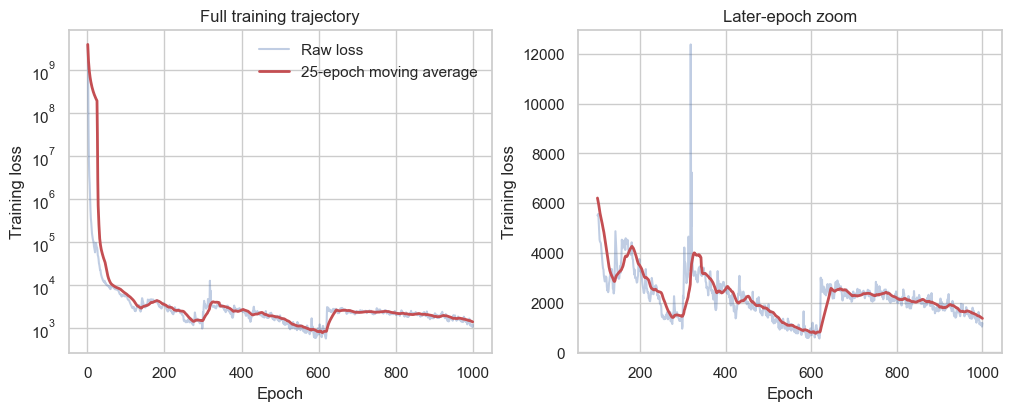

Create training loss figure finished in 0.73 seconds


In [8]:
step_start = time.perf_counter()
df_loss = plot_training_loss(model.train_loss, '../results/figures/Figure2.pdf', window_size=25)
print_step_time('Create training loss figure', step_start)

## 7. Estimate the MetVAE sparse correlation matrix

We first generate the MetVAE correlation estimate through repeated imputations, then apply p-value-based sparsification. 

In [9]:
step_start = time.perf_counter()
model.get_corr(num_sim=100, workers=-1, seed=0)
print_step_time('Estimate MetVAE correlations', step_start)

step_start = time.perf_counter()
results_metvae = model.sparse_by_p(p_adj_method='fdr_bh', cutoff=0.001)
est_cor = results_metvae['sparse_estimate']
print_step_time('Sparsify MetVAE correlations', step_start)

print('Sparse correlation matrix shape:', est_cor.shape)
display(est_cor.iloc[:5, :5])

Estimate MetVAE correlations finished in 34.11 seconds


Sparsify MetVAE correlations finished in 2.71 seconds
Sparse correlation matrix shape: (7217, 7217)


,1,2,3,4,5
1,1.000000,0.834172,0.495156,0.644358,0.862824
2,0.834172,1.000000,0.534524,0.550532,0.868173
3,0.495156,0.534524,1.000000,0.393286,0.565067
4,0.644358,0.550532,0.393286,1.000000,0.669336
5,0.862824,0.868173,0.565067,0.669336,1.000000


## 8. Optional note: export correlation-only GraphML directly from MetVAE

MetVAE can export GraphML directly from the sparse correlation matrix. We keep that code here for reference, but we do not run it because the analysis below adds correlation edges onto an existing cosine-similarity graph.

In [10]:
# model.export_graphml(
#     sparse_df=est_cor,
#     cutoffs=[0.7],
#     output_dir='../results',
#     file_prefix='hcc_correlation_graph_cutoff',
# )

## 9. Load the cosine graph used as the attribute template

The next section builds a correlation graph and then copies node attributes from the original cosine graph so the exported GraphML retains the same node metadata.

In [11]:
step_start = time.perf_counter()
G_cosine_full = nx.read_graphml('../data/hcc_graph.graphml')
print_step_time('Load cosine graph', step_start)

print('Directed graph:', G_cosine_full.is_directed())
print(f"{G_cosine_full.number_of_nodes()} nodes, {G_cosine_full.number_of_edges()} edges")

edges_cosine_full = nx.to_pandas_edgelist(G_cosine_full)
print('Edge attributes:')
print(list(edges_cosine_full.columns))
print('Cosine score distribution:')
display(edges_cosine_full['cosine_score'].describe())

Load cosine graph finished in 14.26 seconds
Directed graph: False
7713 nodes, 146818 edges


Edge attributes:
['source', 'target', 'property1', 'EdgeScore', 'mass_difference', 'component', 'id', 'node1', 'EdgeAnnotation', 'explained_intensity', 'cosine_score', 'EdgeType', 'node2']
Cosine score distribution:


count    146818.000000
mean          0.646726
std           0.186435
min           0.101400
25%           0.518600
50%           0.634600
75%           0.778400
max           1.000000
Name: cosine_score, dtype: float64

## 10. Build and export the MetVAE correlation graph

We convert the sparse MetVAE matrix into a long edge table, apply the `|correlation| >= 0.7` cutoff, build a NetworkX graph, copy node attributes from the cosine graph, and export the GraphML file.

In [12]:
step_start = time.perf_counter()
metvae_edge_table = build_upper_triangle_edge_table(est_cor)
print_step_time('Convert MetVAE matrix to edge table', step_start)

print('MetVAE edge table shape:', metvae_edge_table.shape)
display(metvae_edge_table.head())

Convert MetVAE matrix to edge table finished in 4.16 seconds
MetVAE edge table shape: (26038936, 3)


,source,target,correlation
23239915,5130,6343,0.999316
17424556,3214,6525,0.999251
25865290,7052,7174,0.999192
23909591,5444,7343,0.998986
24461346,5761,6175,0.998797


In [13]:
step_start = time.perf_counter()
G_corr_metvae, metvae_edges_07 = build_correlation_graph(metvae_edge_table, cutoff=0.7, template_graph=G_cosine_full)
print_step_time('Build MetVAE correlation graph', step_start)

print(f"Number of edges with |correlation| >= 0.7: {len(metvae_edges_07)}")
print(f"Graph has {G_corr_metvae.number_of_nodes()} nodes and {G_corr_metvae.number_of_edges()} edges")

Build MetVAE correlation graph finished in 0.48 seconds
Number of edges with |correlation| >= 0.7: 22470
Graph has 3973 nodes and 22470 edges


In [14]:
step_start = time.perf_counter()
os.makedirs('../results/outputs', exist_ok=True)
metvae_graphml_path = '../results/outputs/hcc_correlation_graph_cutoff0.7.graphml'
nx.write_graphml(G_corr_metvae, metvae_graphml_path)
print_step_time('Write MetVAE GraphML', step_start)
print(f'Saved: {metvae_graphml_path}')

Write MetVAE GraphML finished in 7.82 seconds
Saved: ../results/outputs/hcc_correlation_graph_cutoff0.7.graphml


## Runtime summary

The table below summarizes the timed steps in the order they were recorded.

In [15]:
runtime_summary = pd.Series(step_times, name='seconds').rename_axis('step').reset_index()
display(runtime_summary)
print(f"Total tracked time: {runtime_summary['seconds'].sum():.2f} seconds")

,step,seconds
0,Load input tables,0.316629
1,Preprocess and align samples,0.006787
2,Build abundance matrix,0.014112
3,Load MetVAE checkpoint,2.399477
4,Create training loss figure,0.728024
5,Estimate MetVAE correlations,34.114093
6,Sparsify MetVAE correlations,2.707185
7,Load cosine graph,14.257305
8,Convert MetVAE matrix to edge table,4.163633
9,Build MetVAE correlation graph,0.475159


Total tracked time: 67.01 seconds
